ChatBot Using LangGraph


In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

# new import for memory feature
from langgraph.checkpoint.memory import MemorySaver
load_dotenv()

True

In [2]:
from langgraph.graph import add_messages
from typing import TypedDict,Annotated
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

In [3]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.7
)
def Chat_node(state : ChatState):

    messages = state['messages']

    response = llm.invoke(messages)

    return {'messages' : response}



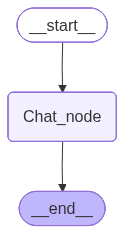

In [ ]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('Chat_node' , Chat_node)

# add edges

graph.add_edge(START , 'Chat_node')
graph.add_edge('Chat_node' , END)

chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [7]:
initial_state = {
    'messages' : [HumanMessage(content="what is the capital of pakistan")]

}
chatbot.invoke(initial_state)['messages'][-1].content

'The capital of Pakistan is Islamabad.'

Now we will develope Chating Feature , but still not maintaining memory

In [6]:
thread_id = '1'

while True:
    user_message = input('type here')

    if user_message.strip().lower() in ['exit' , 'quit' , 'bye']: 
        break

    config = {'configurable' : {'thread_id' : thread_id}}
    response = chatbot.invoke({'messages' : [HumanMessage(content=user_message)]}, config = config)

    print(' Ai : ' , response['messages'][-1].content)

 Ai It's nice to meet you. Is there something I can help you with or would you like to chat?
 Ai Nice to meet you, Zahir. It's lovely to have you here. How's your day going so far? Is there something on your mind that you'd like to talk about, or would you like some conversation starters?
 Ai Your name is Zahir. You told me that earlier.
 Ai It seems like you didn't type anything. If you'd like to continue our conversation, I'm here to chat with you, Zahir.
 Ai It looks like you didn't type anything again. Feel free to start a conversation or ask me a question, and I'll do my best to help, Zahir.
 Ai To calculate the result, I'll add 10 to 100.

100 + 10 = 110

The result is 110.
 Ai To calculate the result, I'll multiply 110 by 2.

110 × 2 = 220

The result is 220.


In [7]:
chatbot.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='86d54ff8-1c77-4753-af42-52518c0e738f'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.042491629, 'completion_tokens_details': None, 'prompt_time': 0.000950414, 'prompt_tokens_details': None, 'queue_time': 0.393052777, 'total_time': 0.043442043}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db3ba-f7b2-7213-907d-7b44b173fdbe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59}), HumanMessage(content='my name is zahir', additional_kwargs={}, response_metadata={}, id